# One-Shot Learning using a Siamese Network in FastEstimator

[[Paper](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf)] [[Notebook](https://github.com/fastestimator/fastestimator/blob/master/apphub/one_shot_learning/siamese_network/siamese.ipynb)] [[Torch Implementation](https://github.com/fastestimator/fastestimator/blob/master/apphub/one_shot_learning/siamese_network/siamese_torch.py)]

This notebook demonstrates how to perform one-shot learning using a Siamese Network in FastEstimator.

In one-shot learning we classify based on only a single example of each class. This ability to learn from very little data could be useful in many machine learning problems. 

We will use the Omniglot dataset for training and evaluation. The Omniglot dataset consists of 50 different alphabets split into background (30 alphabets) and evaluation (20 alphabets) sets. Each alphabet has a number of characters, with 20 images for each character.

In [1]:
import tempfile

import os
import cv2
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as fn
import fastestimator as fe

from matplotlib import pyplot as plt

## Building Components

In [2]:
# Parameters
epochs = 200
batch_size = 128
train_steps_per_epoch = None
eval_steps_per_epoch = None
save_dir = tempfile.mkdtemp()
data_dir = None

### Step 1: Create `Pipeline`

In [ ]:
from fastestimator.dataset.data import omniglot

train_data, eval_data = omniglot.load_data(root_dir=data_dir)
test_data = eval_data.split(0.5)

For training, batches of data are created with half of the batch consisting of image pairs drawn from the same character, and the other half consisting of image pairs drawn from different characters. The target label is 1 for image pairs from the same character and 0 otherwise. The aim is to learn to quantify similarity between any given pair of images.

In [4]:
from fastestimator.op.numpyop.meta import Sometimes
from fastestimator.op.numpyop.multivariate import ShiftScaleRotate
from fastestimator.op.numpyop.univariate import Minmax, ReadImage, Reshape

pipeline = fe.Pipeline(
    train_data=train_data,
    eval_data=eval_data,
    test_data=test_data,
    batch_size=batch_size,
    ops=[
        ReadImage(inputs="x_a", outputs="x_a", color_flag="gray"),
        ReadImage(inputs="x_b", outputs="x_b", color_flag="gray"),
        Sometimes(
            ShiftScaleRotate(image_in="x_a",
                             image_out="x_a",
                             shift_limit=0.05,
                             scale_limit=0.2,
                             rotate_limit=10.0,
                             mode="train"),
            prob=0.89),
        Sometimes(
            ShiftScaleRotate(image_in="x_b",
                             image_out="x_b",
                             shift_limit=0.05,
                             scale_limit=0.2,
                             rotate_limit=10.0,
                             mode="train"),
            prob=0.89),
        Minmax(inputs="x_a", outputs="x_a"),
        Minmax(inputs="x_b", outputs="x_b"),
        Reshape(shape=(1, 105, 105), inputs="x_a", outputs="x_a"),
        Reshape(shape=(1, 105, 105), inputs="x_b", outputs="x_b")
    ])

We can visualize sample images from the `Pipeline` using the `get_results` method:

Image pair from different characters


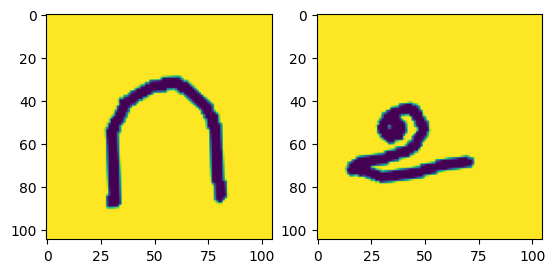

Image pair from same character


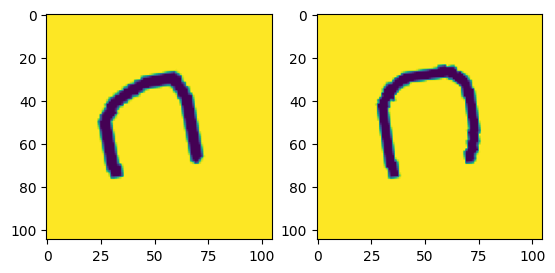

In [ ]:
sample_batch = pipeline.get_results()

pair1_img_a = sample_batch["x_a"][0]
pair1_img_b = sample_batch["x_b"][0]

pair2_img_a = sample_batch["x_a"][1]
pair2_img_b = sample_batch["x_b"][1]

if sample_batch["y"][0] ==1:
    print('Image pair from same character')
else:
    print('Image pair from different characters')

plt.subplot(121)
plt.imshow(np.squeeze(pair1_img_a))

plt.subplot(122)
plt.imshow(np.squeeze(pair1_img_b))

plt.show()

if sample_batch["y"][1] ==1:
    print('Image pair from same character')
else:
    print('Image pair from different characters')

plt.subplot(121)
plt.imshow(np.squeeze(pair2_img_a))

plt.subplot(122)
plt.imshow(np.squeeze(pair2_img_b))

plt.show()

### Step 2: Create `Network`

Our siamese network has two convolutional arms which accept distinct inputs. However, the weights on both these convolutional arms are shared. Each convolutional arm works as a feature extractor which produces a feature vector. L1 component-wise distance between these vectors is computed which is used to classify whether the image pair belongs to the same or different classes (characters). 

In [6]:
class SiameseNetwork(nn.Module):
    """Network Architecture"""
    def __init__(self, classes=1):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 10)
        self.conv2 = nn.Conv2d(64, 128, 7)
        self.conv3 = nn.Conv2d(128, 128, 4)
        self.conv4 = nn.Conv2d(128, 256, 4)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.normal_(m.bias, mean=0.5, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.2)
                nn.init.normal_(m.bias, mean=0.5, std=0.01)

    def branch_forward(self, x):
        x = self.conv1(x)
        x = fn.max_pool2d(x, 2)
        x = fn.relu(x)

        x = self.conv2(x)
        x = fn.max_pool2d(x, 2)
        x = fn.relu(x)

        x = self.conv3(x)
        x = fn.max_pool2d(x, 2)
        x = fn.relu(x)

        x = self.conv4(x)
        x = fn.relu(x)

        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        x = torch.sigmoid(x)
        return x

    def forward(self, x):
        x1 = self.branch_forward(x[0])
        x2 = self.branch_forward(x[1])
        x = torch.abs(x1 - x2)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x

We now prepare the `model` and define a `Network` object.

In [7]:
from fastestimator.op.tensorop.loss import CrossEntropy
from fastestimator.op.tensorop.model import ModelOp, UpdateOp

model = fe.build(model_fn=SiameseNetwork, model_name="siamese_net", optimizer_fn="adam")

network = fe.Network(ops=[
    ModelOp(inputs=["x_a", "x_b"], model=model, outputs="y_pred"),
    CrossEntropy(inputs=("y_pred", "y"), outputs="loss", form="binary"),
    UpdateOp(model=model, loss_name="loss")
])

In this example we will also use the following traces:
1. LRScheduler with a constant decay schedule as described in the [paper](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf).
2. BestModelSaver for saving the best model. For illustration purpose, we will save these models in a temporary directory.
3. EarlyStopping for stopping training if the monitored metric doesn't improve within a specified number of epochs.
4. A custom trace to calculate one shot classification accuracy as described in the [paper](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf).
This trace performs a 20-way within-alphabet classification task in which an alphabet is first chosen from among those reserved for the evaluation set. Then, nineteen other characters are taken uniformly at random from the alphabet. The first character's image is compared with another image of the same character and with images of the other nineteen characters. This is called a one-shot trial. The trial is considered a success if the network outputs the highest similarity (probability) score for the image pair belonging to same character. 

In [ ]:
from fastestimator.backend import feed_forward, to_tensor
from fastestimator.trace import Trace
from fastestimator.op.tensorop import TensorOp
from fastestimator.trace.adapt import EarlyStopping, LRScheduler
from fastestimator.trace.io import BestModelSaver
from fastestimator.trace.metric import Accuracy
from fastestimator.util import Data

def lr_schedule(epoch):
    """Learning rate schedule"""
    lr = 0.0001 * np.power(0.99, epoch)
    return lr


class L2Regularization(TensorOp):
    """Custom layer level L2 Regularization"""
    def __init__(self, inputs, model, outputs, mode="train"):
        self.model = model
        super().__init__(inputs=inputs, outputs=outputs, mode=mode)

    def forward(self, data, state):
        loss = data
        l2_loss = 0
        for name, m in self.model.named_modules():
            if isinstance(m, nn.Conv2d):
                l2_loss += 0.01 * torch.sum(torch.mul(m.weight, m.weight))
            elif isinstance(m, nn.Linear):
                if name == "fc1":
                    l2_loss += 0.0001 * torch.sum(torch.mul(m.weight, m.weight))
        return loss + l2_loss


class OneShotAccuracy(Trace):
    """Trace for calculating one shot accuracy"""
    def __init__(self, dataset, model, N=20, trials=400, mode=("eval", "test"), output_name="one_shot_accuracy"):

        super().__init__(mode=mode, outputs=output_name)
        self.dataset = dataset
        self.model = model
        self.total = 0
        self.correct = 0
        self.output_name = output_name
        self.N = N
        self.trials = trials

    def on_epoch_begin(self, data: Data):
        self.total = 0
        self.correct = 0

    def on_epoch_end(self, data: Data):
        device = next(self.model.parameters()).device
        for _ in range(self.trials):
            img_path = self.dataset.one_shot_trial(self.N)
            input_img = (np.array([
                np.expand_dims(cv2.imread(i, cv2.IMREAD_GRAYSCALE), -1).reshape((1, 105, 105)) / 255.
                for i in img_path[0]
            ],
                                  dtype=np.float32),
                         np.array([
                             np.expand_dims(cv2.imread(i, cv2.IMREAD_GRAYSCALE), -1).reshape((1, 105, 105)) / 255.
                             for i in img_path[1]
                         ],
                                  dtype=np.float32))

            input_img = (to_tensor(input_img[0], "torch").to(device), to_tensor(input_img[1], "torch").to(device))
            model = self.model.module if torch.cuda.device_count() > 1 else self.model
            prediction_score = feed_forward(model, input_img, training=False).cpu().detach().numpy()

            if np.argmax(prediction_score) == 0 and prediction_score.std() > 0.01:
                self.correct += 1

            self.total += 1

        data.write_with_log(self.outputs[0], self.correct / self.total)


traces = [
    LRScheduler(model=model, lr_fn=lr_schedule),
    Accuracy(true_key="y", pred_key="y_pred"),
    OneShotAccuracy(dataset=eval_data, model=model, output_name='one_shot_accuracy'),
    BestModelSaver(model=model, save_dir=save_dir, metric="one_shot_accuracy", save_best_mode="max"),
    EarlyStopping(monitor="one_shot_accuracy", patience=20, compare='max', mode="eval")
]

### Step 3: Create `Estimator`

In [ ]:
estimator = fe.Estimator(network=network,
                         pipeline=pipeline,
                         epochs=epochs,
                         traces=traces,
                         train_steps_per_epoch=train_steps_per_epoch,
                         eval_steps_per_epoch=eval_steps_per_epoch)

## Training and Testing

In [ ]:
# Training
estimator.fit()

Now, we can load the best model to check its one-shot accuracy on the test set:

In [11]:
# Testing
fe.backend.load_model(model, os.path.join(save_dir, 'siamese_net_best_one_shot_accuracy.pt'))
estimator.test()

FastEstimator-Test: step: 302; epoch: 200; accuracy: 0.6959090909090909; loss: 0.6135178; one_shot_accuracy: 0.2025;


## Inferencing

Let's perform inferencing on some elements in the test dataset. Here, we generate a 5-way one shot trial for demo purposes.

In [21]:
#Generating one-shot trial set for 5-way one shot trial
img_path = test_data.one_shot_trial(5)
input_img = (np.array([np.expand_dims(cv2.imread(i, cv2.IMREAD_GRAYSCALE), 0) / 255. for i in img_path[0]],
                      dtype=np.float32),
             np.array([np.expand_dims(cv2.imread(i, cv2.IMREAD_GRAYSCALE), 0) / 255. for i in img_path[1]],
                      dtype=np.float32))

prediction_score = feed_forward(model, input_img, training=False).detach().numpy()

The test image is predicted to be belonging to the class with the maximum similarity. 

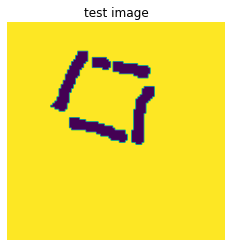

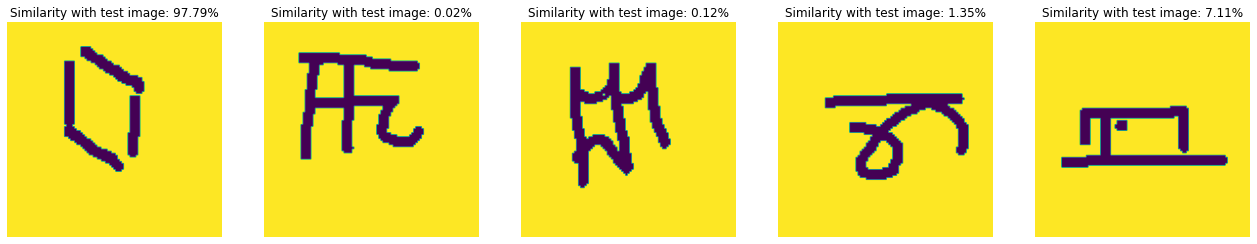

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(np.squeeze(input_img[0][0]));
plt.title('test image')
plt.axis('off');
plt.show()

plt.figure(figsize=(18, 18))
plt.subplot(151)
plt.imshow(np.squeeze(input_img[1][0]));
plt.title('Similarity with test image: {:0.2f}%'.format(100*prediction_score[0][0]))
plt.axis('off');

plt.subplot(152)
plt.imshow(np.squeeze(input_img[1][1]));
plt.title('Similarity with test image: {:0.2f}%'.format(100*prediction_score[1][0]))
plt.axis('off');

plt.subplot(153)
plt.imshow(np.squeeze(input_img[1][2]));
plt.title('Similarity with test image: {:0.2f}%'.format(100*prediction_score[2][0]))
plt.axis('off');

plt.subplot(154)
plt.imshow(np.squeeze(input_img[1][3]));
plt.title('Similarity with test image: {:0.2f}%'.format(100*prediction_score[3][0]))
plt.axis('off');

plt.subplot(155)
plt.imshow(np.squeeze(input_img[1][4]));
plt.title('Similarity with test image: {:0.2f}%'.format(100*prediction_score[4][0]))
plt.axis('off');

plt.tight_layout()